In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("space_missions_dataset.csv")

print("=" * 60)
print("INFORMAÇÕES DA BASE")
print("=" * 60)

print(df.head())
print("\nQuantidade de registros:", len(df))

INFORMAÇÕES DA BASE
  Mission ID Mission Name Launch Date Target Type Target Name  Mission Type  \
0   MSN-0001    Mission-1  2025-01-01        Star       Titan  Colonization   
1   MSN-0002    Mission-2  2025-01-08   Exoplanet  Betelgeuse  Colonization   
2   MSN-0003    Mission-3  2025-01-15    Asteroid        Mars   Exploration   
3   MSN-0004    Mission-4  2025-01-22   Exoplanet       Titan  Colonization   
4   MSN-0005    Mission-5  2025-01-29   Exoplanet   Proxima b        Mining   

   Distance from Earth (light-years)  Mission Duration (years)  \
0                               7.05                       5.2   
1                              41.76                      23.0   
2                              49.22                      28.8   
3                              26.33                      17.8   
4                               8.67                       9.2   

   Mission Cost (billion USD)  Scientific Yield (points)  Crew Size  \
0                      526.68        

In [3]:

# =====================================================
# TABELA DE FREQUÊNCIA
# VARIÁVEL QUANTITATIVA DISCRETA
# Crew Size
# =====================================================

print("\n" + "=" * 60)
print("TABELA DE FREQUÊNCIA - CREW SIZE")
print("=" * 60)

freq_abs = df["Crew Size"].value_counts().sort_index()

freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

freq_acum = freq_abs.cumsum()

tabela_discreta = pd.DataFrame({
    "Frequência Absoluta": freq_abs,
    "Frequência Relativa (%)": freq_rel,
    "Frequência Acumulada": freq_acum
})

print(tabela_discreta)


TABELA DE FREQUÊNCIA - CREW SIZE
           Frequência Absoluta  Frequência Relativa (%)  Frequência Acumulada
Crew Size                                                                    
1                            6                      1.2                     6
2                            4                      0.8                    10
3                            4                      0.8                    14
4                            3                      0.6                    17
5                            5                      1.0                    22
...                        ...                      ...                   ...
95                           1                      0.2                   480
96                           6                      1.2                   486
97                           8                      1.6                   494
98                           4                      0.8                   498
99                           2

In [4]:
# =====================================================
# TABELA DE FREQUÊNCIA
# VARIÁVEL QUANTITATIVA CONTÍNUA
# Payload Weight (tons)
# =====================================================

print("\n" + "=" * 60)
print("TABELA DE FREQUÊNCIA - PAYLOAD WEIGHT")
print("=" * 60)

payload = df["Payload Weight (tons)"]

classes = pd.cut(payload, bins=10)

freq_abs2 = classes.value_counts().sort_index()

freq_rel2 = (freq_abs2 / freq_abs2.sum() * 100).round(2)

freq_acum2 = freq_abs2.cumsum()

tabela_continua = pd.DataFrame({
    "Frequência Absoluta": freq_abs2,
    "Frequência Relativa (%)": freq_rel2,
    "Frequência Acumulada": freq_acum2
})

print(tabela_continua)


TABELA DE FREQUÊNCIA - PAYLOAD WEIGHT
                       Frequência Absoluta  Frequência Relativa (%)  \
Payload Weight (tons)                                                 
(0.921, 10.896]                         48                      9.6   
(10.896, 20.772]                        55                     11.0   
(20.772, 30.648]                        43                      8.6   
(30.648, 40.524]                        49                      9.8   
(40.524, 50.4]                          52                     10.4   
(50.4, 60.276]                          61                     12.2   
(60.276, 70.152]                        50                     10.0   
(70.152, 80.028]                        39                      7.8   
(80.028, 89.904]                        57                     11.4   
(89.904, 99.78]                         46                      9.2   

                       Frequência Acumulada  
Payload Weight (tons)                        
(0.921, 10.896] 

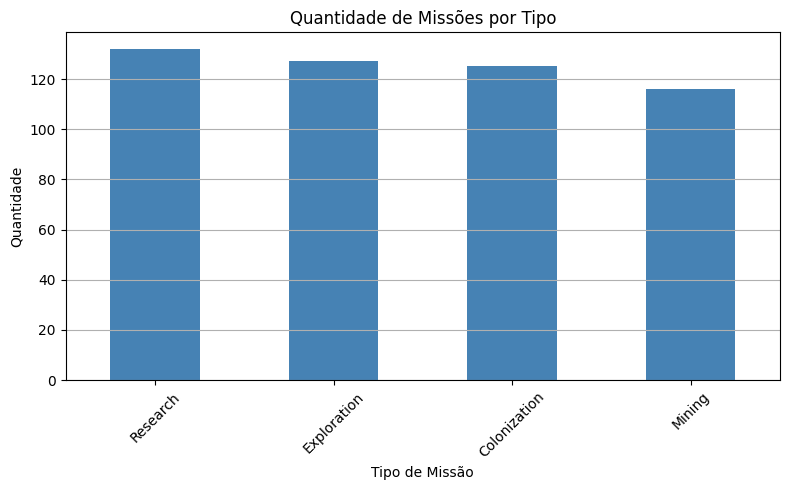

In [5]:
# =====================================================
# GRÁFICO 1
# MISSÕES POR TIPO
# =====================================================

plt.figure(figsize=(8,5))

df["Mission Type"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Quantidade de Missões por Tipo")
plt.xlabel("Tipo de Missão")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

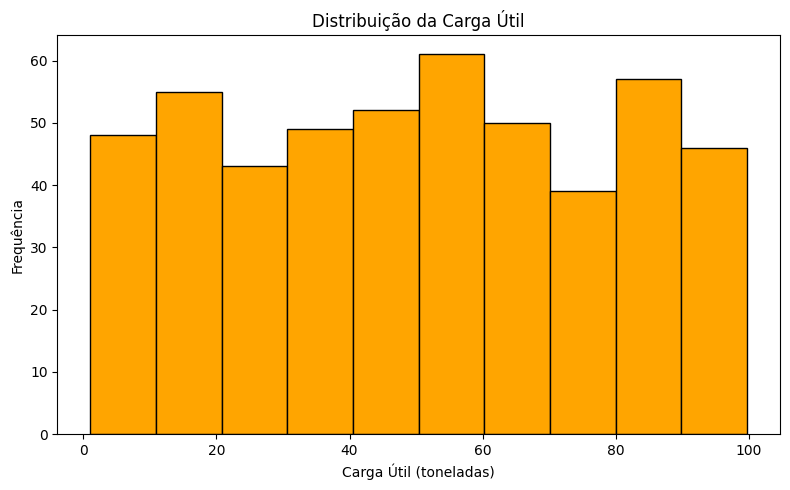

In [6]:
# =====================================================
# GRÁFICO 2
# HISTOGRAMA DA CARGA ÚTIL
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Payload Weight (tons)"],
    bins=10,
    color="orange",
    edgecolor="black"
)

plt.title("Distribuição da Carga Útil")
plt.xlabel("Carga Útil (toneladas)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [7]:
# =====================================================
# ANÁLISE UNIVARIADA 1
# PAYLOAD WEIGHT
# =====================================================

print("\n" + "=" * 60)
print("ANÁLISE UNIVARIADA - PAYLOAD WEIGHT")
print("=" * 60)

serie = df["Payload Weight (tons)"]

print("Média:", serie.mean())
print("Mediana:", serie.median())
print("Moda:", serie.mode()[0])

print("Máximo:", serie.max())
print("Mínimo:", serie.min())

print("Amplitude:", serie.max() - serie.min())

print("Variância:", serie.var())
print("Desvio Padrão:", serie.std())

print("\nQuartis")

print("Q1:", serie.quantile(0.25))
print("Q2:", serie.quantile(0.50))
print("Q3:", serie.quantile(0.75))


ANÁLISE UNIVARIADA - PAYLOAD WEIGHT
Média: 50.355619999999995
Mediana: 50.995
Moda: 6.9
Máximo: 99.78
Mínimo: 1.02
Amplitude: 98.76
Variância: 796.7943589334669
Desvio Padrão: 28.227546101874793

Quartis
Q1: 25.5675
Q2: 50.995
Q3: 74.4825


In [8]:
# =====================================================
# ANÁLISE UNIVARIADA 2
# MISSION COST
# =====================================================

print("\n" + "=" * 60)
print("ANÁLISE UNIVARIADA - MISSION COST")
print("=" * 60)

serie = df["Mission Cost (billion USD)"]

print("Média:", serie.mean())
print("Mediana:", serie.median())
print("Moda:", serie.mode()[0])

print("Máximo:", serie.max())
print("Mínimo:", serie.min())

print("Amplitude:", serie.max() - serie.min())

print("Variância:", serie.var())
print("Desvio Padrão:", serie.std())

print("\nQuartis")

print("Q1:", serie.quantile(0.25))
print("Q2:", serie.quantile(0.50))
print("Q3:", serie.quantile(0.75))


ANÁLISE UNIVARIADA - MISSION COST
Média: 277.30028000000004
Mediana: 282.16999999999996
Moda: 405.66
Máximo: 538.32
Mínimo: 13.32
Amplitude: 525.0
Variância: 19919.771757035676
Desvio Padrão: 141.137421533184

Quartis
Q1: 149.96
Q2: 282.16999999999996
Q3: 399.995


# **INTERPRETAÇÕES**
Payload Weight:
* A média e a mediana permitem avaliar o peso típico
transportado pelas missões. O desvio padrão mostra
o quanto os valores se afastam da média.

Mission Cost:
* Os custos apresentam grande variação entre as missões.
A análise dos quartis ajuda a identificar a distribuição
dos investimentos realizados.